# Proyecto: Despliegue de un modelo de Machine Learning con Streamlit y Render

## Objetivo
Desarrollar una aplicación web con Streamlit que permita utilizar un modelo de Machine Learning para clasificar billetes como auténticos o falsos y preparar el proyecto para su despliegue en Render.

## Paso 1: Entrenamiento del modelo

Se reutiliza el problema de clasificación de billetes auténticos y falsos del proyecto anterior con Flask.

Variables:
- `variance`
- `skewness`
- `curtosis`
- `entropy`

Objetivo:
- `0`: auténtico
- `1`: falso

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columnas = ["variance", "skewness", "curtosis", "entropy", "class"]

df = pd.read_csv(url, header=None, names=columnas)
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df.shape

(1372, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(24)

In [7]:
df["class"].value_counts()

class
0    762
1    610
Name: count, dtype: int64

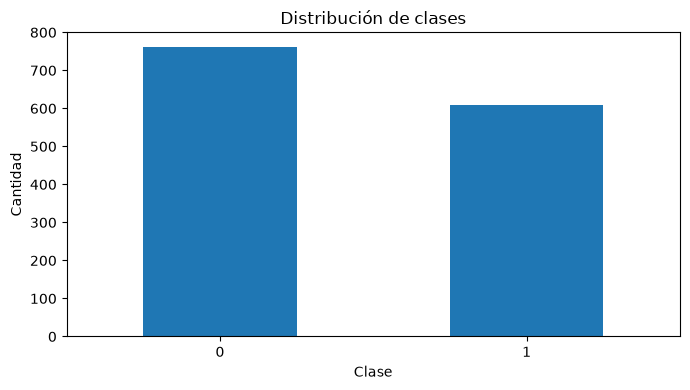

In [8]:
df["class"].value_counts().sort_index().plot(kind="bar", figsize=(7,4))
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación de la variable objetivo
La variable objetivo contiene dos clases con una distribución suficientemente equilibrada para entrenar un modelo de clasificación binaria.

In [9]:
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1097, 4)
Test: (275, 4)


In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

pipeline.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['variance','skewness','curtosis','entropy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [11]:
y_pred = pipeline.predict(X_test)
accuracy_initial = accuracy_score(y_test, y_pred)

print("Accuracy modelo inicial:", round(accuracy_initial, 4))
print()
print(classification_report(y_test, y_pred))

Accuracy modelo inicial: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



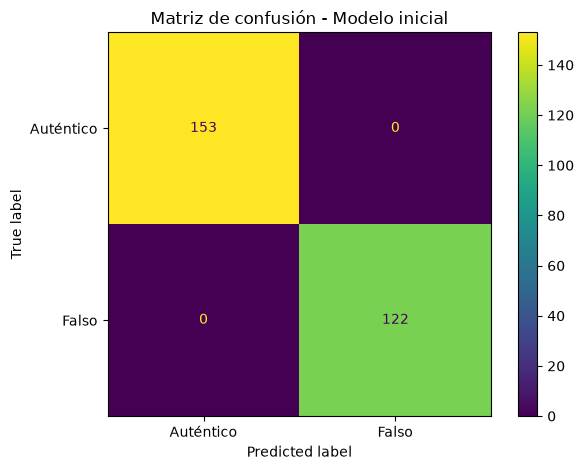

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Auténtico", "Falso"])
disp.plot()
plt.title("Matriz de confusión - Modelo inicial")
plt.tight_layout()
plt.show()

## Optimización del modelo

In [13]:
param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy CV:", round(grid_search.best_score_, 4))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.1

Mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Mejor accuracy CV: 1.0


In [14]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("Accuracy modelo optimizado:", round(accuracy_best, 4))
print()
print(classification_report(y_test, y_pred_best))

Accuracy modelo optimizado: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



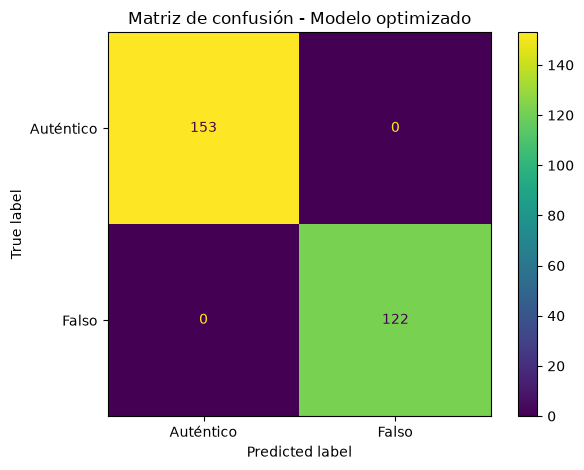

In [15]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm_best, display_labels=["Auténtico", "Falso"])
disp.plot()
plt.title("Matriz de confusión - Modelo optimizado")
plt.tight_layout()
plt.show()

In [16]:
comparacion = pd.DataFrame({
    "Modelo": ["SVM inicial", "SVM optimizado"],
    "Accuracy": [accuracy_initial, accuracy_best]
})
comparacion

,Modelo,Accuracy
0,SVM inicial,1.0
1,SVM optimizado,1.0


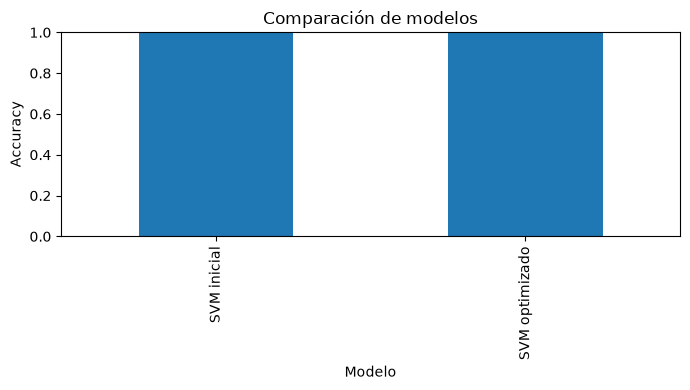

In [17]:
comparacion.set_index("Modelo")["Accuracy"].plot(kind="bar", figsize=(7,4), ylim=(0,1))
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Guardado del modelo

In [18]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "banknote_model.pkl"
joblib.dump(best_model, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ../models/banknote_model.pkl


## Conclusión general

Considerando qué se reutilizo los datos y el mismo tipo de entrenamiento del proyecto anterior la conclusion es la misma, pero el despliegue de la app es utilizando streamlit 

Conclusion anterior

El modelo SVM mostró un desempeño sobresaliente para la clasificación de billetes auténticos y falsos. El conjunto de datos presenta una distribución relativamente equilibrada entre ambas clases, lo que permite evaluar el modelo sin un sesgo importante hacia una categoría. Después de dividir los datos en entrenamiento y prueba, se construyó un pipeline que combina estandarización de variables con un clasificador SVM, obteniendo inicialmente un accuracy aproximado de 99.63%. La matriz de confusión confirma este buen comportamiento, con solo 1 clasificación incorrecta de 270 observaciones.

Posteriormente, mediante la optimización de hiperparámetros, el modelo alcanzó un accuracy del 100% en el conjunto de prueba, clasificando correctamente los 148 billetes auténticos y los 122 falsos, sin falsos positivos ni falsos negativos. Los valores de precision, recall y F1-score también alcanzaron 1.00, lo que indica un rendimiento prácticamente perfecto sobre los datos evaluados.

## Enlace de Render

Link: https://ml-web-streamlit-1.onrender.com/